# Our Data

# Objective 2: Solar Cell Power Curve 

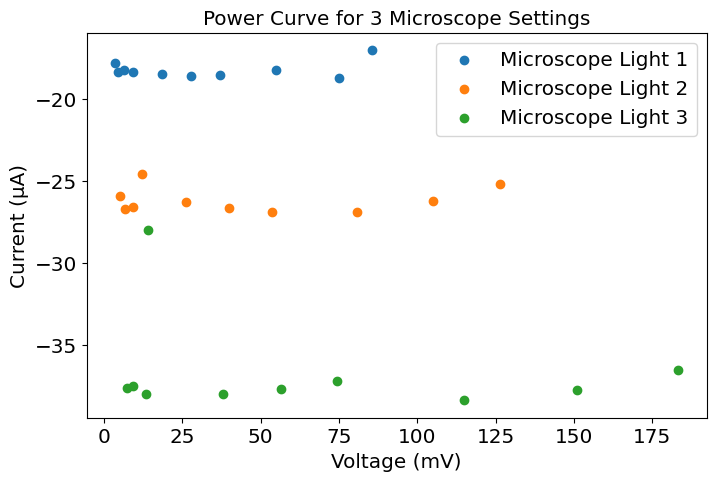

In [23]:
import numpy as np
import matplotlib.pyplot as plt
R = np.array( [8,          28,    38.7,    45.6,   53.2, 61.4, 66.6, 72.2, 100.0, 150, 196.6, 250.7, 350, 500, 1000, 1.5e3, 2.0e3, 3.0e3, 4.0e3, 5.02e3])
V1 = np.array([0.0e-3, 0.3e-3,  0.7e-3,   0.8e-3,  1.0e-3, 1.1e-3, 1.2e-3, 1.3e-3, 1.8e-3, 2.5e-3, 3.5e-3, 4.6e-3, 6.4e-3, 9.2e-3, 18.5e-3, 27.9e-3, 37.1e-3, 54.8e-3, 75e-3, 85.6e-3])
V2 = np.array([0.1e-3, 0.4e-3,  0.9e-3,   1.1e-3,  1.4e-3, 1.6e-3, 1.6e-3, 1.8e-3, 2.6e-3, 3.7e-3, 5.1e-3, 6.7e-3, 9.3e-3, 12.3e-3, 26.3e-3, 40.0e-3, 53.8e-3, 80.8e-3, 105e-3, 126.5e-3])
V3 = np.array([0.1e-3, 0.6e-3,  1.5e-3,   1.6e-3,  2.0e-3, 2.3e-3, 2.5e-3, 2.7e-3, 3.8e-3, 5.5e-3, 7.4e-3, 9.4e-3, 13.3e-3, 14.0e-3, 38.0e-3, 56.5e-3, 74.4e-3, 115.1e-3, 151e-3, 183.4e-3])
V4 = np.array([3.5e-3, 22.6e-3, 44.2e-3,  52.4e-3, 63.5e-3, 81e-3, 100e-3, 102e-3, 121.8e-3, 202e-3, 290e-3, 370e-3, 0.49, 0.55, 0.58, 0.583, 0.585, 0.589, 0.593, 0.585])

plt.figure(figsize=(8,5))
plt.scatter(1e3*V1[10:], -1e6*V1[10:]/R[10:], label="Microscope Light 1")
# plt.xlabel("Voltage")
# plt.ylabel("Current")
# plt.title("Miscrope Light 1")
# plt.show()
plt.scatter(1e3*V2[10:], -1e6*V2[10:]/R[10:], label="Microscope Light 2")
# plt.xlabel("Voltage")
# plt.ylabel("Current")
# plt.title("Miscrope Light 2")
# plt.show()

plt.scatter(1e3*V3[10:], -1e6*V3[10:]/R[10:], label="Microscope Light 3")
plt.xlabel("Voltage (mV)")
plt.ylabel("Current (μA)")
plt.title("Power Curve for 3 Microscope Settings")
plt.legend()
plt.show()
# plt.scatter(V4[10:], -V4[10:]/R[10:])
# plt.xlabel("Voltage")
# plt.ylabel("Current")
# plt.title("Floodlamp")
# plt.show()

In [24]:
import matplotlib.pyplot as plt

def get_cost_function(V, I_ph = 10e-3, I_0 = 25e-10, eta=1.5):
    # From Week 5
    R_s = 8
    def cost_function(I):
        return np.abs(-I_ph + I_0*np.exp((V-I*R_s) / (eta*0.0259)) - I_0 - I)
    
    return cost_function

def calculate_IV_curves(voltage, I_ph = 15e-4, I_0 = 3e-10, eta=1.5):
    # R_s = 0
    _I = np.linspace(-0.02, 0.01, 100000)
    
    # minimize(cost_function, I, method='nelder-mead')
    current = np.zeros_like(voltage)
    for i, v in enumerate(voltage):
        cost_function = get_cost_function(v, I_ph, I_0, eta)
        current[i] = _I[np.argmin(cost_function(_I))]

    return current

/tmp/ipykernel_71869/3984195558.py:3: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(calculate_IV_curves, V4[10:], -V4[10:]/R[10:], p0=[15e-4, 3e-10, 1.5])


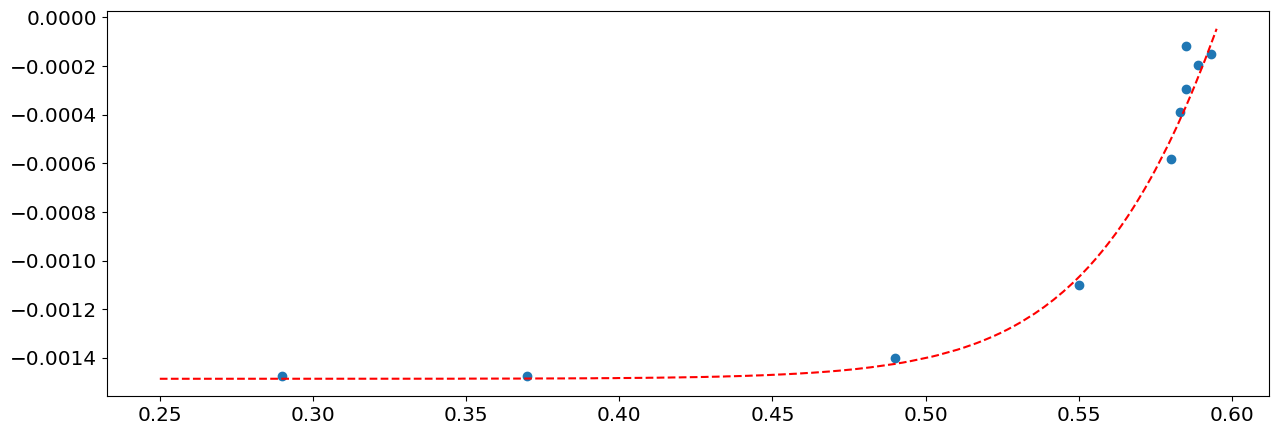

In [25]:
from scipy.optimize import curve_fit

popt, pcov = curve_fit(calculate_IV_curves, V4[10:], -V4[10:]/R[10:], p0=[15e-4, 3e-10, 1.5])

voltage = np.linspace(0.25, 0.595, 1000)
I = calculate_IV_curves(voltage, 14.86e-4, 0.03e-10, 1.15)
plt.scatter(V4[10:], -V4[10:]/R[10:])
plt.plot(voltage, I, "r--")

/tmp/ipykernel_71869/1377934907.py:12: RuntimeWarning: invalid value encountered in log
  return eta*0.0259 * np.log((current+I_0+I_ph)/I_0) + current*R_s


[1.486e-03 3.000e-12 1.150e+00]


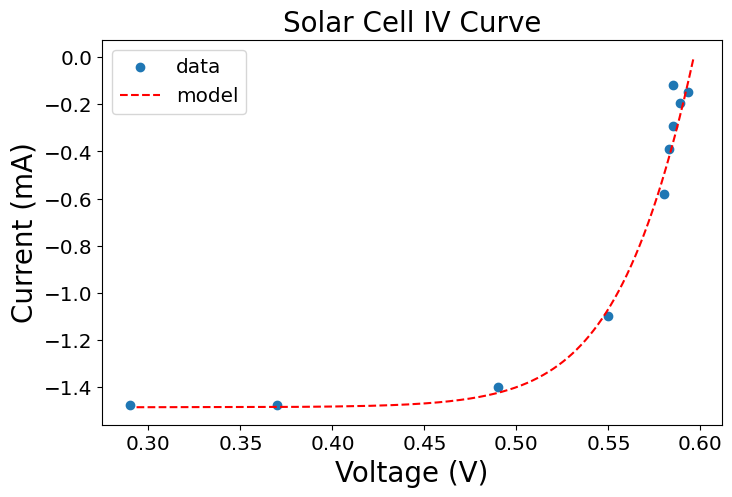

In [26]:
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
plt.rcParams.update(params)

I = np.linspace(-1.48591486e-03, 0, 1000)
def v_from_i(current, I_ph = 14.86e-4, I_0 = 0.03e-10, eta=1.15):
    R_s = 8
    return eta*0.0259 * np.log((current+I_0+I_ph)/I_0) + current*R_s

# popt, pcov = curve_fit(v_from_i, -V4[10:]/R[10:], V4[10:], p0=[14.86e-4, 0.03e-10, 1.15], method = 'dogbox')
popt, pcov = curve_fit(v_from_i, -V4[10:]/R[10:], V4[10:], p0=[14.86e-4, 0.03e-10, 1.15], method = 'trf')

plt.figure(figsize=(8, 5))
plt.scatter(V4[10:], -1e3*V4[10:]/R[10:], label="data")
plt.plot(v_from_i(I, popt[0], popt[1], popt[2]), 1e3*I, "r--", label="model")
plt.xlabel("Voltage (V)", fontsize=20)
plt.ylabel("Current (mA)", fontsize=20)
plt.title("Solar Cell IV Curve", fontsize=20)
plt.legend()
print(popt)

In [27]:
I

array([-1.48591486e-03, -1.48442746e-03, -1.48294006e-03, -1.48145265e-03,
       -1.47996525e-03, -1.47847785e-03, -1.47699045e-03, -1.47550304e-03,
       -1.47401564e-03, -1.47252824e-03, -1.47104084e-03, -1.46955344e-03,
       -1.46806603e-03, -1.46657863e-03, -1.46509123e-03, -1.46360383e-03,
       -1.46211642e-03, -1.46062902e-03, -1.45914162e-03, -1.45765422e-03,
       -1.45616681e-03, -1.45467941e-03, -1.45319201e-03, -1.45170461e-03,
       -1.45021721e-03, -1.44872980e-03, -1.44724240e-03, -1.44575500e-03,
       -1.44426760e-03, -1.44278019e-03, -1.44129279e-03, -1.43980539e-03,
       -1.43831799e-03, -1.43683059e-03, -1.43534318e-03, -1.43385578e-03,
       -1.43236838e-03, -1.43088098e-03, -1.42939357e-03, -1.42790617e-03,
       -1.42641877e-03, -1.42493137e-03, -1.42344396e-03, -1.42195656e-03,
       -1.42046916e-03, -1.41898176e-03, -1.41749436e-03, -1.41600695e-03,
       -1.41451955e-03, -1.41303215e-03, -1.41154475e-03, -1.41005734e-03,
       -1.40856994e-03, -

In [28]:
V = v_from_i(I, popt[0], popt[1], popt[2])
P = np.abs(I*V)
V_oc = V[-1] 
I_sc = popt[0]
V_prime = V[np.argmax(P)]
I_prime = I[np.argmax(P)]

# plt.plot(1e3*V, 1e3*I, "r--", label="model")
# plt.plot(1e3*V, 1e6*np.abs(I*V), label=r"$P_{out}$")
# plt.xlabel("Voltage (mv)")
# # plt.ylabel("Current (mA)")
# # plt.axvline(1e3*V_oc, color="blue", linestyle=":", label=r"$V_{oc}$ and $I_{sc}$")
# # plt.axhline(-1e3*I_sc, color="blue", linestyle=":",)
# plt.axvline(1e3*0.55, color="blue", linestyle="-", label=r"$V^{'}$ and $I^{'}$")
# plt.axhline(-1e3*0.0012, color="blue", linestyle="-",)
# plt.scatter(1e3*V4[10:], -1e3*V4[10:]/R[10:])
# plt.legend()

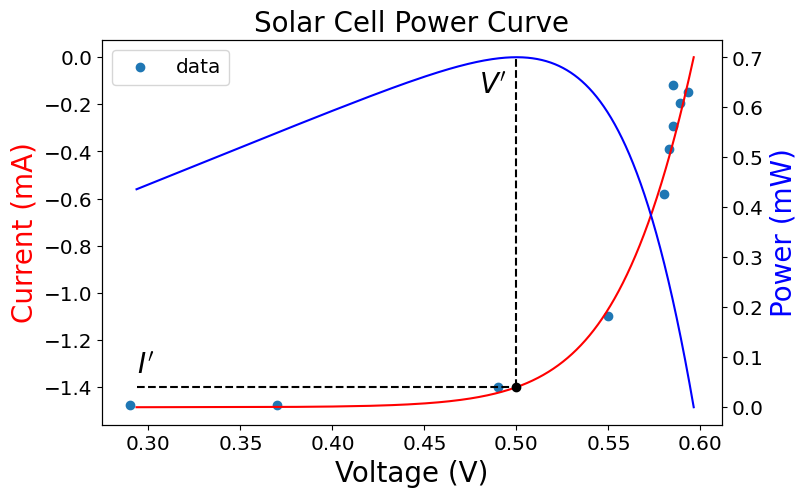

In [29]:
fig, ax1 = plt.subplots(figsize=(8, 5))

vertical_offset1 = 0.06

vertical_offset2 = -0.15
horizontal_offset2 = .020


ax1.plot(V, 1e3*I, color="red")
ax1.vlines(V[np.argmax(P)], ymin=1e3*I_prime, ymax=0, linestyle="--", color="black")
ax1.hlines(1e3*I[np.argmax(P)], xmin=np.min(V), xmax=V_prime, linestyle="--", color="black")
ax1.scatter(V_prime, 1e3*I_prime, color='black', zorder=10)
# ax1.axhline(1e3*I[np.argmax(P)], linestyle="--", color="black")
ax1.set_xlabel("Voltage (V)", fontsize=20)
ax1.set_ylabel('Current (mA)', color="red", fontsize=20)
ax1.annotate(r"$I'$", (np.min(V), 1e3*I_prime + vertical_offset1), fontsize=20)
ax1.annotate(r"$V'$", (V_prime - horizontal_offset2, np.max(I)+vertical_offset2), fontsize=20)
ax1.scatter(V4[10:], -1e3*V4[10:]/R[10:], label="data")
# ax1.tick_params(axis='y', labelcolor='r')

ax2 = ax1.twinx()
ax2.plot(V, 1e3*P, color='b', label='P_out')
ax2.set_ylabel('Power (mW)', color='blue', fontsize=20)

plt.title("Solar Cell Power Curve", fontsize=20)
ax1.legend()


In [30]:
print(V_prime)
print(I_prime)
print(V_prime*I_prime)

0.49984150316424053
-0.0014011329310510512
-0.0007003443903894756


# Objective 3: Photovoltaics in Series

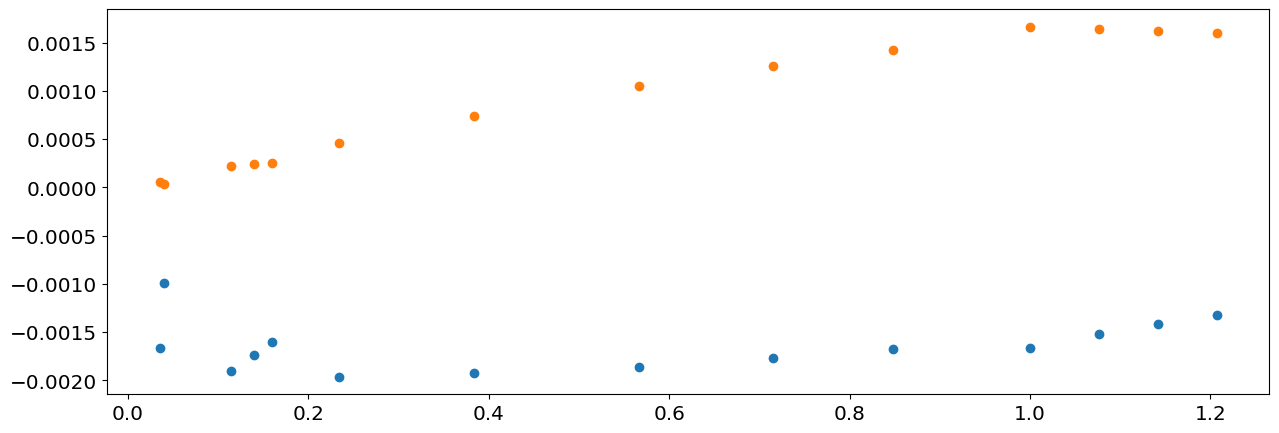

In [31]:
# R = np.array([21.2, 40.0, 59.6, 80.8, 100.0, 119.4, 200, 304, 405, 506, 601, 709, 807, 909, 1006, 1500])
# V = np.array([0.0352, 0.0397, 0.1137, 0.140, 0.160, 0.2344, 0.384, 0.566, 0.715, 0.848, 1.0, 1.077, 1.142, 1.207, 2.277, 0.200])
R = np.array([21.2, 40.0, 59.6, 80.8, 100.0, 119.4, 200, 304, 405, 506, 601, 709, 807, 909])
V = np.array([0.0352, 0.0397, 0.1137, 0.140, 0.160, 0.2344, 0.384, 0.566, 0.715, 0.848, 1.0, 1.077, 1.142, 1.207])
I = -V/R
P = np.abs(-I*V)
V_oc = V[-1] 
I_sc = popt[0]
V_prime = V[np.argmax(P)]
I_prime = I[np.argmax(P)]

plt.scatter(V, I)
plt.scatter(V, P)

-0.0016638935108153079
1.0
-0.0016638935108153079


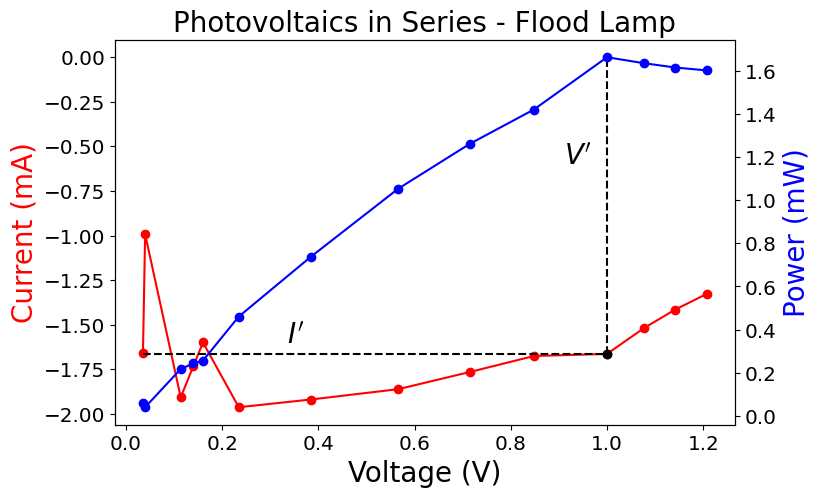

In [32]:
fig, ax1 = plt.subplots(figsize=(8, 5))

vertical_offset1 = 0.06
horizontal_offset1 = .300

vertical_offset2 = -0.6
horizontal_offset2 = -.090


ax1.plot(V, 1e3*I,"r-o", label='Current (mA)', )
ax1.vlines(V[np.argmax(P)], ymin=1e3*I_prime, ymax=0, linestyle="--", color="black")
ax1.hlines(1e3*I[np.argmax(P)], xmin=np.min(V), xmax=V_prime, linestyle="--", color="black")
ax1.scatter(V_prime, 1e3*I_prime, color='black', zorder=10)
# ax1.axhline(1e3*I[np.argmax(P)], linestyle="--", color="black")
ax1.set_xlabel("Voltage (V)", fontsize=20)
ax1.set_ylabel('Current (mA)', color="red", fontsize=20)
ax1.annotate(r"$I'$", (np.min(V) + horizontal_offset1, 1e3*I_prime + vertical_offset1), fontsize=20)
ax1.annotate(r"$V'$", (V_prime + horizontal_offset2, 0+vertical_offset2), fontsize=20)
# ax1.tick_params(axis='y', labelcolor='r')

ax2 = ax1.twinx()
ax2.plot(V, 1e3*P, 'b-o', label='P_out')
ax2.set_ylabel('Power (mW)', color='blue', fontsize=20)

plt.title("Photovoltaics in Series - Flood Lamp", fontsize=20)

print(I_prime)
print(V_prime)
print(I_prime*V_prime)


# Section 4's Data

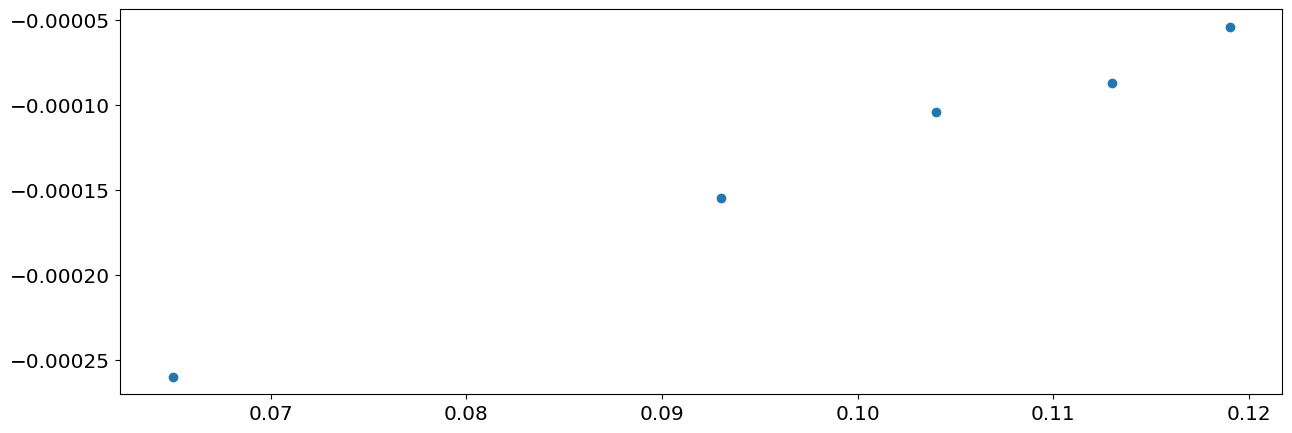

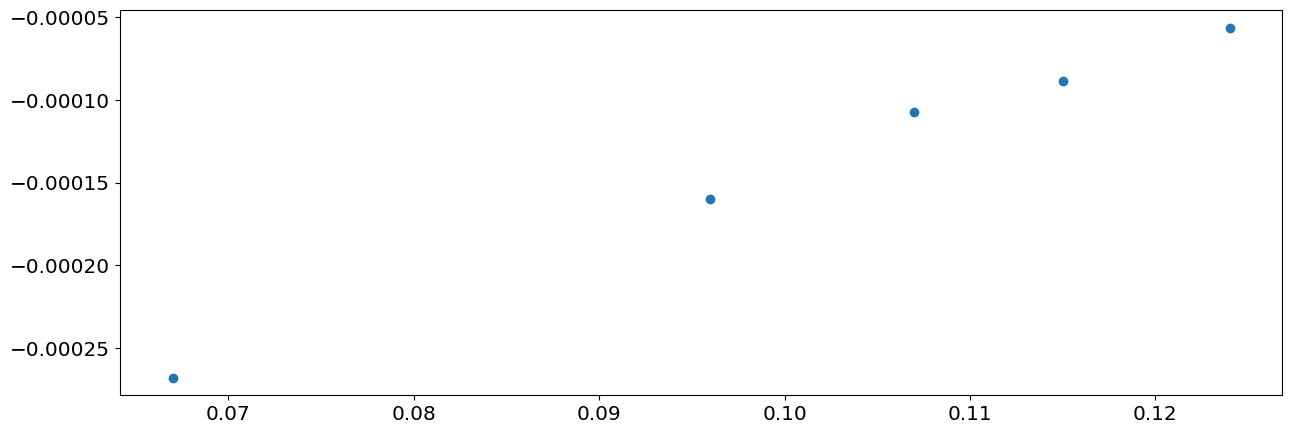

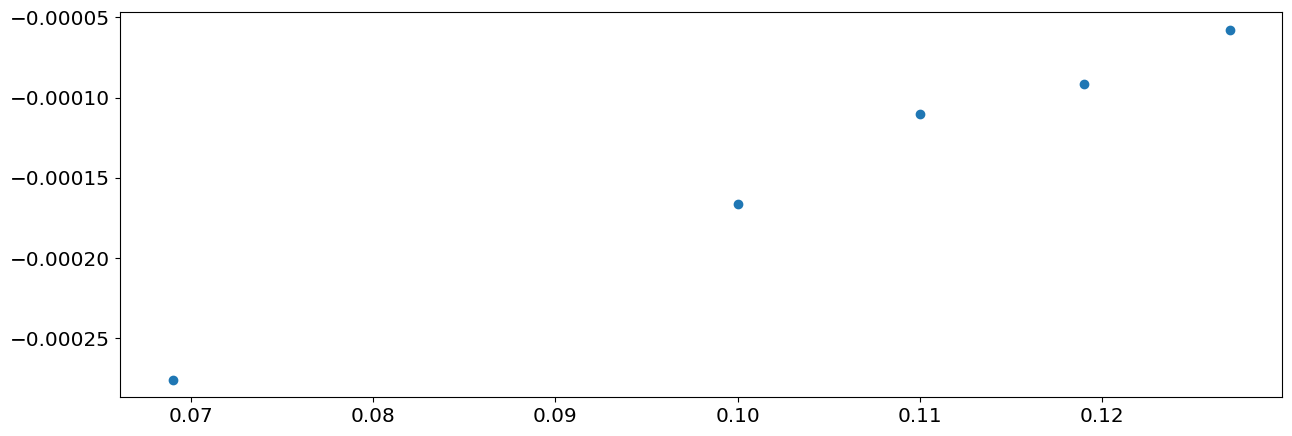

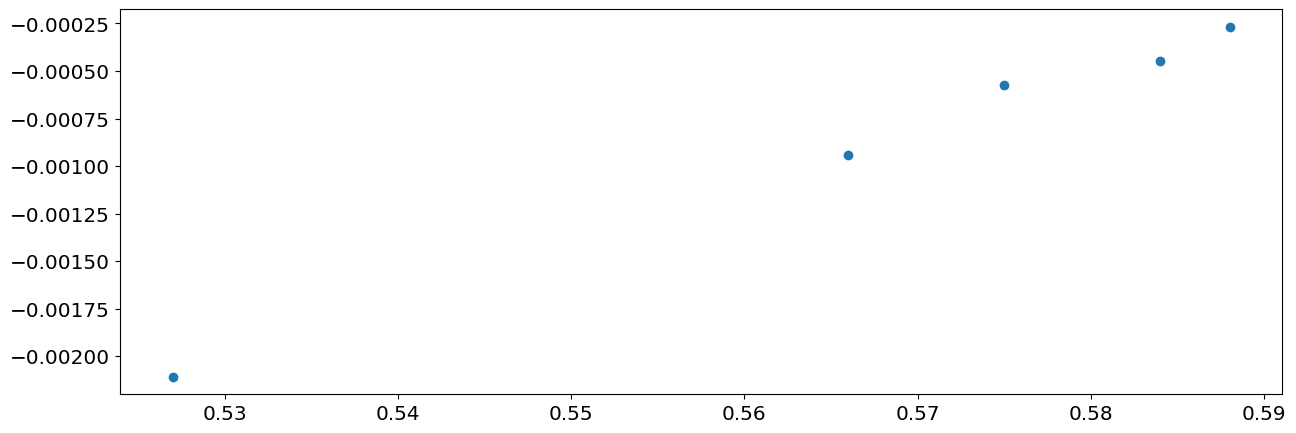

In [33]:
R = np.array([250, 600, 1000, 1300, 2200])
V1 = np.array([0.065, 0.093, 0.104, 0.113, 0.119])
V2 = np.array([0.067, 0.096, 0.107, 0.115, 0.124])
V3 = np.array([0.069, 0.100, 0.110, 0.119, 0.127])
V4 = np.array([0.527, 0.566, 0.575, 0.584, 0.588])

plt.scatter(V1, -V1/R)
plt.show()
plt.scatter(V2, -V2/R)
plt.show()
plt.scatter(V3, -V3/R)
plt.show()
plt.scatter(V4, -V4/R)
plt.show()

# Objective 3 - Photovoltaics in Series

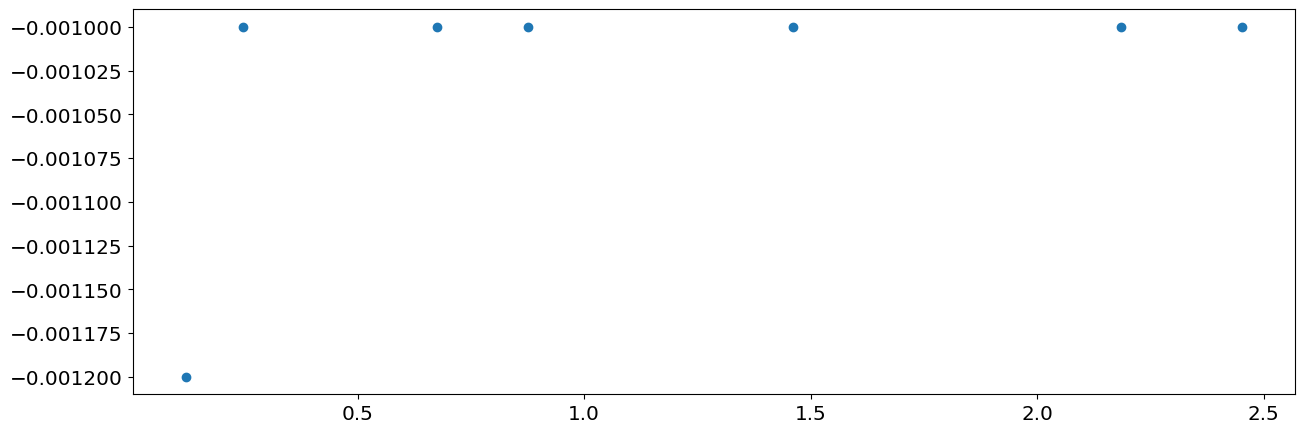

In [34]:
R = np.array([100, 247, 676, 877, 1460, 2185, 2453])
V = np.array([0.120, 0.247, 0.676, 0.877, 1.46, 2.185, 2.453])

plt.scatter(V, -V/R)
plt.show()

# Objective 4 - Photovoltaics in parallel

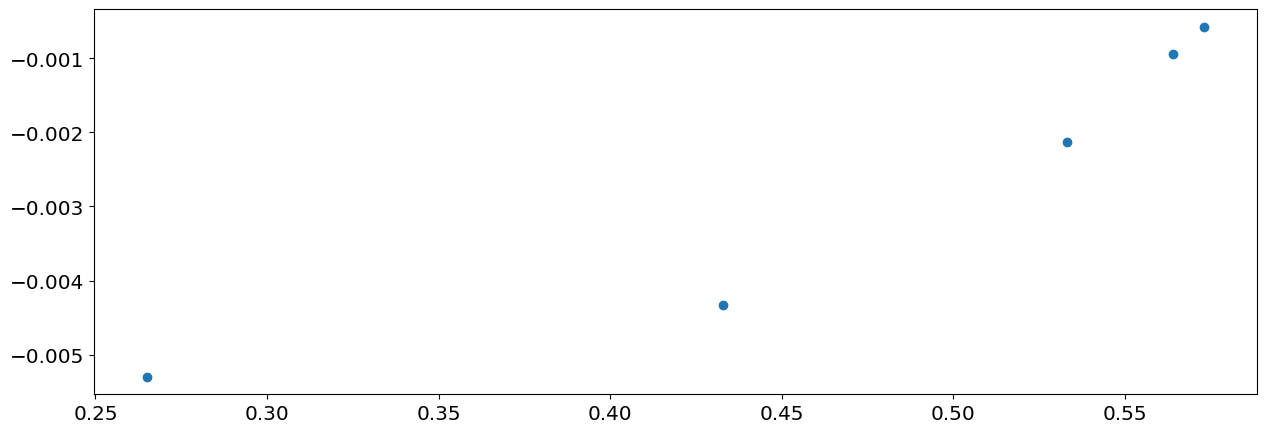

In [35]:
R = np.array([50, 100, 250, 600, 1000])
V = np.array([0.265, 0.433, 0.533, 0.564, 0.573])

plt.scatter(V, -V/R)
plt.show()

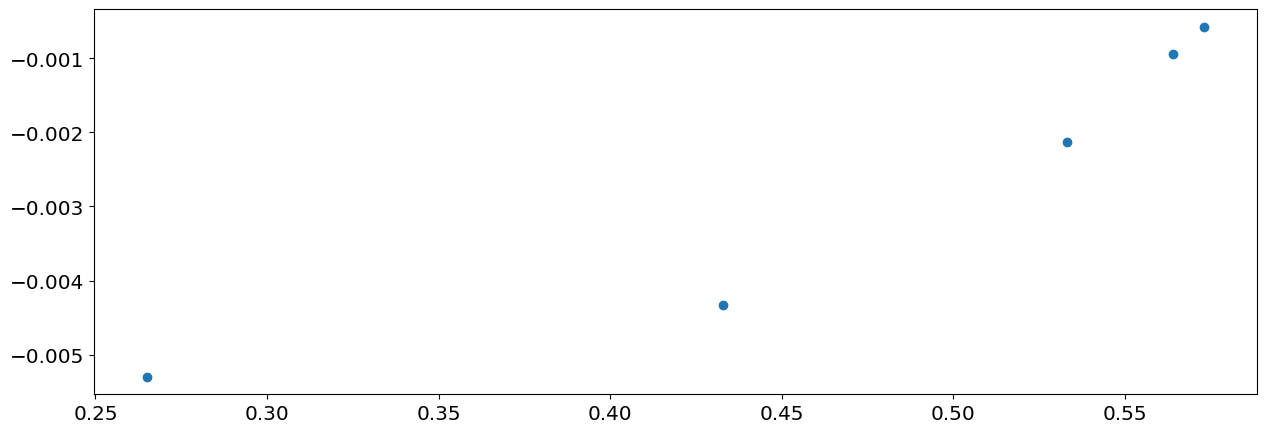

In [36]:
R = np.array([50, 100, 250, 600, 1000])
V = np.array([0.265, 0.433, 0.533, 0.564, 0.573])

plt.scatter(V, -V/R)
plt.show()

# Section 2's Data

Object 2: Single Solar Cell

In [ ]:
R = np.array([2, 5, 10, 25, 50, 100, 200, 300, 400, 1000, 2000, 3000, 4000, 5000])
V = 1e-3*np.array([0.5, 1.4, 2.6, 4.8, 6.4, 6.8, 7.2, 7.3, 8.5, 9.1, 9.0, 8.6, 8.8, 8.8])
I = -V/R
P = np.abs(I*V)

-0.00019199999999999998
0.0048
-9.215999999999998e-07
-25.0


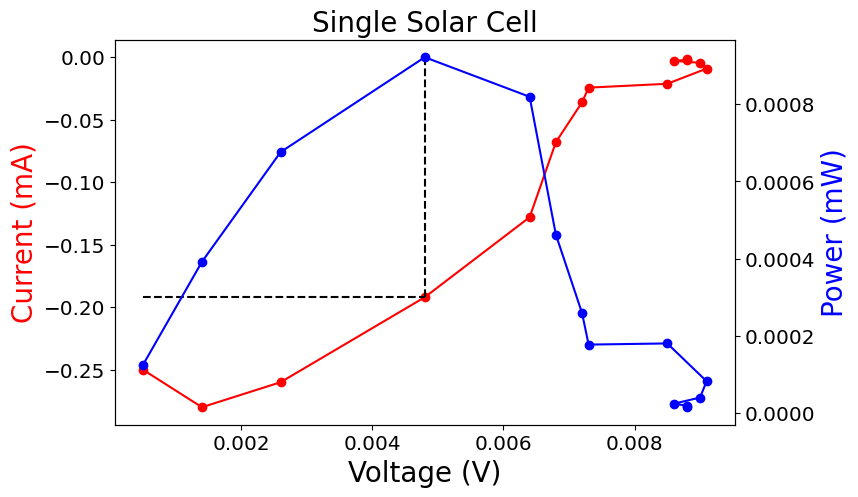

In [47]:
I = -V/R
P = np.abs(-I*V)
V_oc = V[-1] 
I_sc = popt[0]
V_prime = V[np.argmax(P)]
I_prime = I[np.argmax(P)]

fig, ax1 = plt.subplots(figsize=(8, 5))

vertical_offset1 = 0.02
horizontal_offset1 = .600

vertical_offset2 = -0.3
horizontal_offset2 = -.140


ax1.plot(V, 1e3*I,"r-o", label='Current (mA)', )
ax1.vlines(V[np.argmax(P)], ymin=1e3*I_prime, ymax=0, linestyle="--", color="black")
ax1.hlines(1e3*I[np.argmax(P)], xmin=np.min(V), xmax=V_prime, linestyle="--", color="black")
# ax1.scatter(V_prime, 1e3*I_prime, color='black', zorder=10)
# ax1.axhline(1e3*I[np.argmax(P)], linestyle="--", color="black")
ax1.set_xlabel("Voltage (V)", fontsize=20)
ax1.set_ylabel('Current (mA)', color="red", fontsize=20)
ax1.annotate(r"$I'$", (np.min(V) + horizontal_offset1, 1e3*I_prime + vertical_offset1), fontsize=20)
ax1.annotate(r"$V'$", (V_prime + horizontal_offset2, 0+vertical_offset2), fontsize=20)
# ax1.tick_params(axis='y', labelcolor='r')

ax2 = ax1.twinx()
ax2.plot(V, 1e3*P, 'b-o', label='P_out')
ax2.set_ylabel('Power (mW)', color='blue', fontsize=20)

plt.title("Single Solar Cell", fontsize=20)

print(I_prime)
print(V_prime)
print(I_prime*V_prime)
print(V_prime/I_prime)


# Objective 3: Photovoltaics in Series

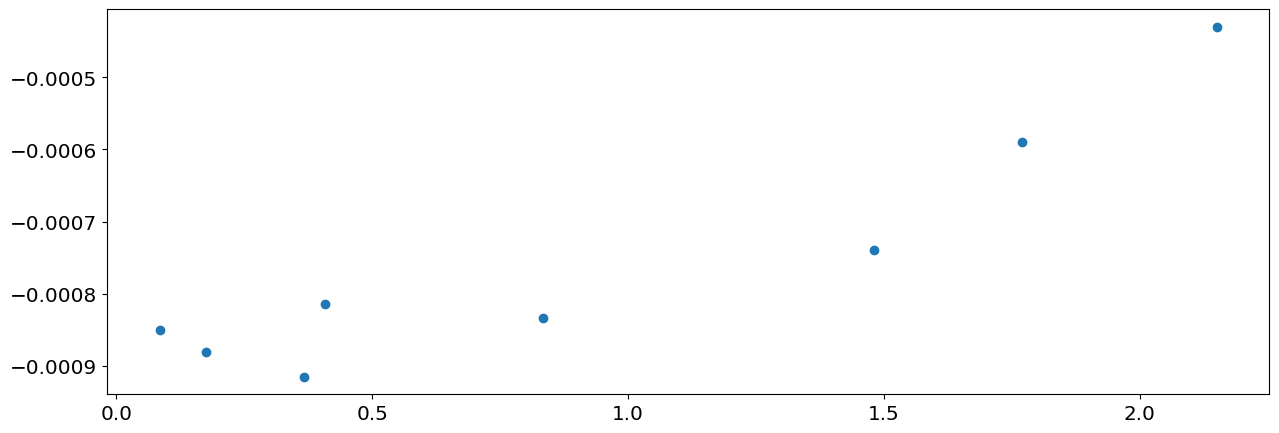

In [ ]:
R = np.array([100, 200, 400, 500, 1000, 2000,  3000, 5000])
V = np.array([0.085, 0.176, 0.366, 0.407, 0.833, 1.48,  1.770, 2.150])

plt.scatter(V, -V/R)


-0.00074
1.48
-0.0010952
-2000.0


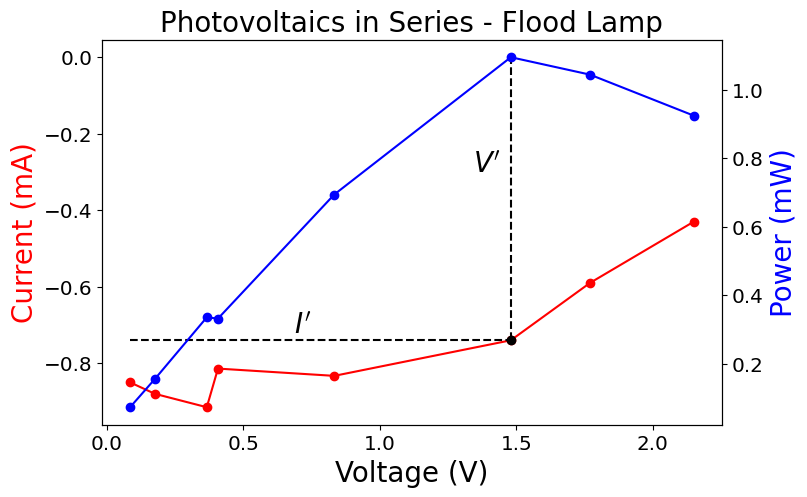

In [38]:
I = -V/R
P = np.abs(-I*V)
V_oc = V[-1] 
I_sc = popt[0]
V_prime = V[np.argmax(P)]
I_prime = I[np.argmax(P)]

fig, ax1 = plt.subplots(figsize=(8, 5))

vertical_offset1 = 0.02
horizontal_offset1 = .600

vertical_offset2 = -0.3
horizontal_offset2 = -.140


ax1.plot(V, 1e3*I,"r-o", label='Current (mA)', )
ax1.vlines(V[np.argmax(P)], ymin=1e3*I_prime, ymax=0, linestyle="--", color="black")
ax1.hlines(1e3*I[np.argmax(P)], xmin=np.min(V), xmax=V_prime, linestyle="--", color="black")
ax1.scatter(V_prime, 1e3*I_prime, color='black', zorder=10)
# ax1.axhline(1e3*I[np.argmax(P)], linestyle="--", color="black")
ax1.set_xlabel("Voltage (V)", fontsize=20)
ax1.set_ylabel('Current (mA)', color="red", fontsize=20)
ax1.annotate(r"$I'$", (np.min(V) + horizontal_offset1, 1e3*I_prime + vertical_offset1), fontsize=20)
ax1.annotate(r"$V'$", (V_prime + horizontal_offset2, 0+vertical_offset2), fontsize=20)
# ax1.tick_params(axis='y', labelcolor='r')

ax2 = ax1.twinx()
ax2.plot(V, 1e3*P, 'b-o', label='P_out')
ax2.set_ylabel('Power (mW)', color='blue', fontsize=20)

plt.title("Photovoltaics in Series - Flood Lamp", fontsize=20)

print(I_prime)
print(V_prime)
print(I_prime*V_prime)
print(V_prime/I_prime)


# Objective 4: Photovoltaics in Parallel

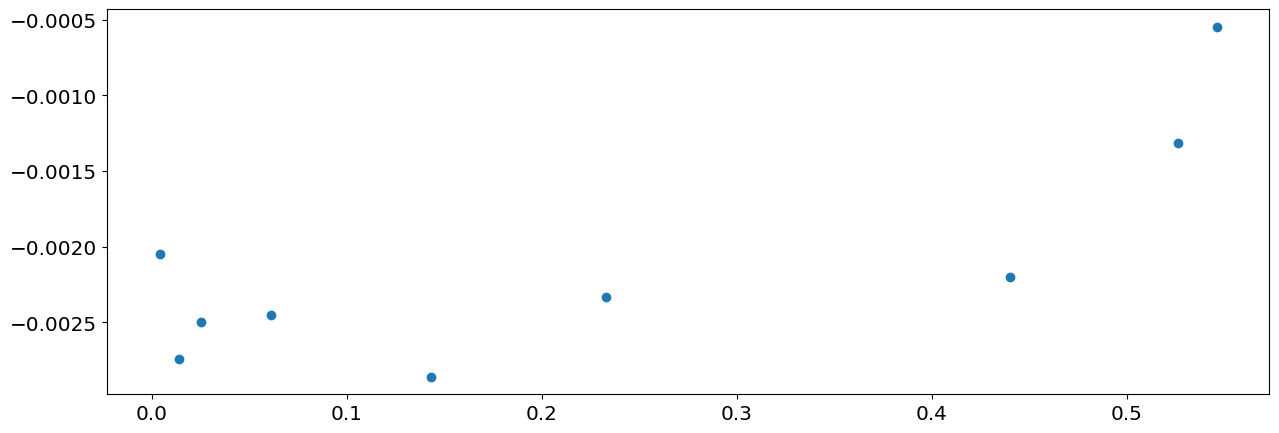

In [39]:
R = np.array([2, 5, 10, 25, 50, 100, 200, 400, 1000])
V = np.array([.0041, .0137, .025, .0613, .143, .233, .440, .526, .546])

plt.scatter(V, -V/R)

-0.0022
0.44
-0.0009680000000000001
-0.0006199167467178995
-200.0


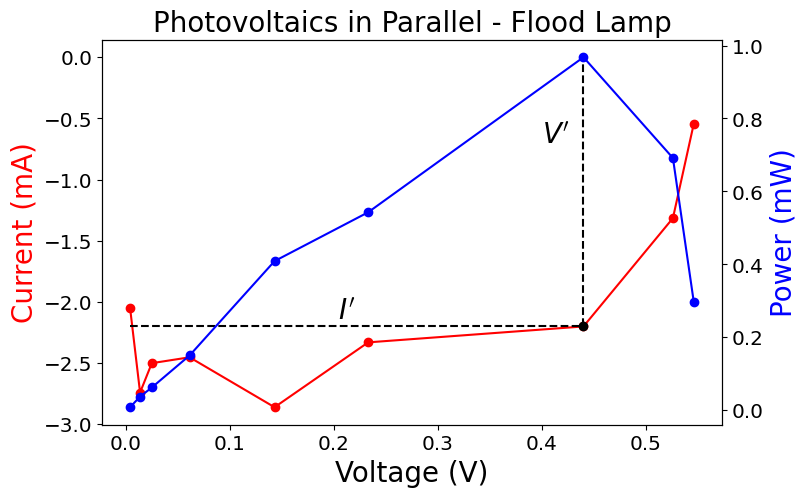

In [40]:
I = -V/R
P = np.abs(-I*V)
V_oc = V[-1] 
I_sc = popt[0]
V_prime = V[np.argmax(P)]
I_prime = I[np.argmax(P)]

fig, ax1 = plt.subplots(figsize=(8, 5))

vertical_offset1 = 0.06
horizontal_offset1 = .200

vertical_offset2 = -0.7
horizontal_offset2 = -.040


ax1.plot(V, 1e3*I,"r-o", label='Current (mA)', )
ax1.vlines(V[np.argmax(P)], ymin=1e3*I_prime, ymax=0, linestyle="--", color="black")
ax1.hlines(1e3*I[np.argmax(P)], xmin=np.min(V), xmax=V_prime, linestyle="--", color="black")
ax1.scatter(V_prime, 1e3*I_prime, color='black', zorder=10)
# ax1.axhline(1e3*I[np.argmax(P)], linestyle="--", color="black")
ax1.set_xlabel("Voltage (V)", fontsize=20)
ax1.set_ylabel('Current (mA)', color="red", fontsize=20)
ax1.annotate(r"$I'$", (np.min(V) + horizontal_offset1, 1e3*I_prime + vertical_offset1), fontsize=20)
ax1.annotate(r"$V'$", (V_prime + horizontal_offset2, 0+vertical_offset2), fontsize=20)
# ax1.tick_params(axis='y', labelcolor='r')

ax2 = ax1.twinx()
ax2.plot(V, 1e3*P, 'b-o', label='P_out')
ax2.set_ylabel('Power (mW)', color='blue', fontsize=20)
plt.title("Photovoltaics in Parallel - Flood Lamp", fontsize=20)

print(I_prime)
print(V_prime)
print(I_prime*V_prime)
print(I_prime*V_prime/156.15 * 100)
print(V_prime/I_prime)

# Real Solar Power

Series

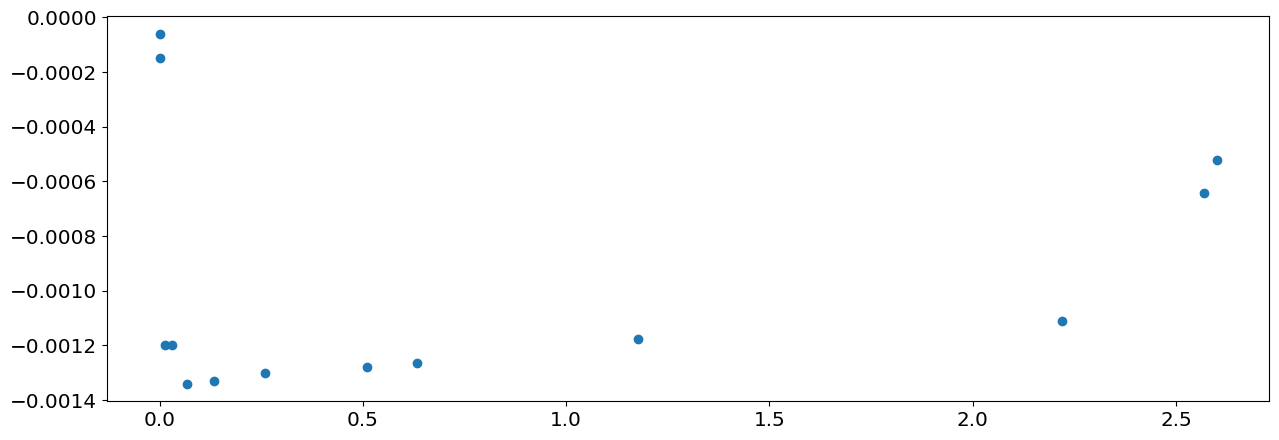

In [41]:
R = np.array([2, 5, 10, 25, 50, 100, 200, 400, 500, 1000, 2000, 4000, 5000])
V = 1e-3*np.array([0.3, 0.3, 12, 30, 67, 133, 260, 511, 632, 1176, 2220, 2570, 2600])

plt.scatter(V, -V/R)

-0.00111
2.22
-0.0024642000000000006
-0.0015780979827089339
-2000.0


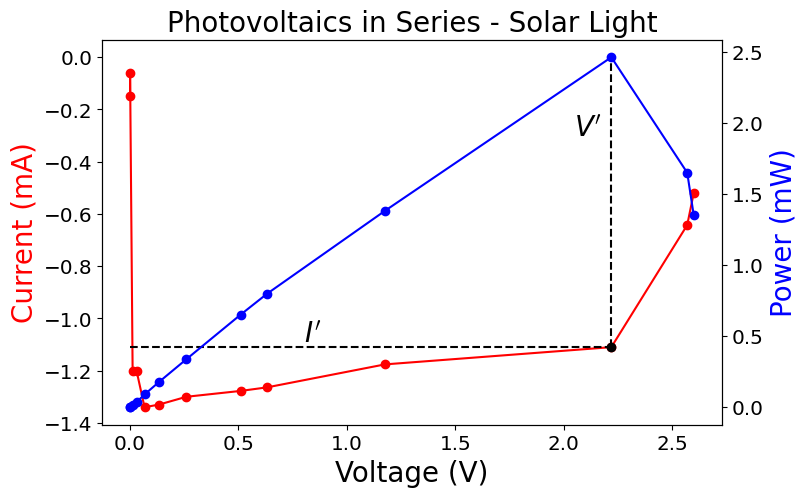

In [42]:
I = -V/R
P = np.abs(-I*V)
V_oc = V[-1] 
I_sc = popt[0]
V_prime = V[np.argmax(P)]
I_prime = I[np.argmax(P)]

fig, ax1 = plt.subplots(figsize=(8, 5))

vertical_offset1 = 0.02
horizontal_offset1 = .800

vertical_offset2 = -0.3
horizontal_offset2 = -.170


ax1.plot(V, 1e3*I,"r-o", label='Current (mA)', )
ax1.vlines(V[np.argmax(P)], ymin=1e3*I_prime, ymax=0, linestyle="--", color="black")
ax1.hlines(1e3*I[np.argmax(P)], xmin=np.min(V), xmax=V_prime, linestyle="--", color="black")
ax1.scatter(V_prime, 1e3*I_prime, color='black', zorder=10)
# ax1.axhline(1e3*I[np.argmax(P)], linestyle="--", color="black")
ax1.set_xlabel("Voltage (V)", fontsize=20)
ax1.set_ylabel('Current (mA)', color="red", fontsize=20)
ax1.annotate(r"$I'$", (np.min(V) + horizontal_offset1, 1e3*I_prime + vertical_offset1), fontsize=20)
ax1.annotate(r"$V'$", (V_prime + horizontal_offset2, 0+vertical_offset2), fontsize=20)
# ax1.tick_params(axis='y', labelcolor='r')

ax2 = ax1.twinx()
ax2.plot(V, 1e3*P, 'b-o', label='P_out')
ax2.set_ylabel('Power (mW)', color='blue', fontsize=20)
plt.title("Photovoltaics in Series - Solar Light", fontsize=20)

print(I_prime)
print(V_prime)
print(I_prime*V_prime)
print(I_prime*V_prime/156.15 *100)
print(V_prime/I_prime)

Parallel

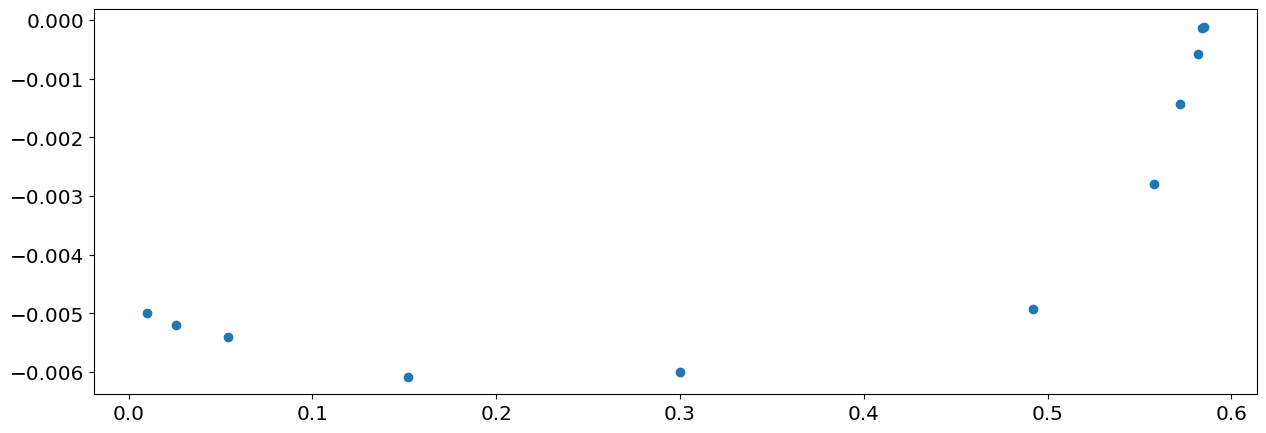

In [43]:
R = np.array([2, 5, 10, 25, 50, 100, 200, 400, 1000, 4000, 5000])
V = 1e-3*np.array([10, 26, 54, 152, 300, 492, 558, 572, 582, 584, 585])

plt.scatter(V, -V/R)

-0.00492
0.492
-0.00242064
-0.0015502017291066281
-100.0


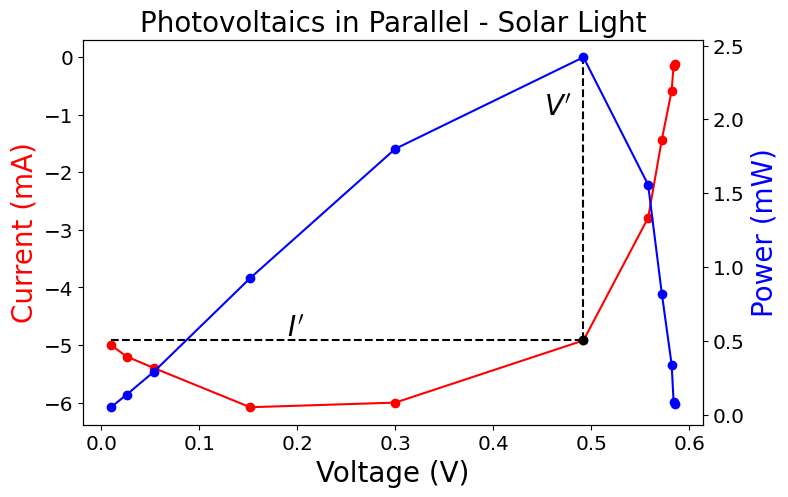

In [44]:
I = -V/R
P = np.abs(-I*V)
V_oc = V[-1] 
I_sc = popt[0]
V_prime = V[np.argmax(P)]
I_prime = I[np.argmax(P)]

fig, ax1 = plt.subplots(figsize=(8, 5))

vertical_offset1 = 0.08
horizontal_offset1 = .180

vertical_offset2 = -1.0
horizontal_offset2 = -.040


ax1.plot(V, 1e3*I,"r-o", label='Current (mA)', )
ax1.vlines(V[np.argmax(P)], ymin=1e3*I_prime, ymax=0, linestyle="--", color="black")
ax1.hlines(1e3*I[np.argmax(P)], xmin=np.min(V), xmax=V_prime, linestyle="--", color="black")
ax1.scatter(V_prime, 1e3*I_prime, color='black', zorder=10)
# ax1.axhline(1e3*I[np.argmax(P)], linestyle="--", color="black")
ax1.set_xlabel("Voltage (V)", fontsize=20)
ax1.set_ylabel('Current (mA)', color="red", fontsize=20)
ax1.annotate(r"$I'$", (np.min(V) + horizontal_offset1, 1e3*I_prime + vertical_offset1), fontsize=20)
ax1.annotate(r"$V'$", (V_prime + horizontal_offset2, 0+vertical_offset2), fontsize=20)
# ax1.tick_params(axis='y', labelcolor='r')

ax2 = ax1.twinx()
ax2.plot(V, 1e3*P, 'b-o', label='P_out')
ax2.set_ylabel('Power (mW)', color='blue', fontsize=20)

plt.title("Photovoltaics in Parallel - Solar Light", fontsize=20)

print(I_prime)
print(V_prime)
print(I_prime*V_prime)
print(I_prime*V_prime/156.15 *100)
print(V_prime/I_prime)